# **MÓDULO 12 - Pratique**


Abaixo temos um dataframe com as seguintes informações:


**Nome:** O nome de cada indivíduo da base


**Idade:** A idade de cada um deles


**Profissão:** A atual ocupação


**Salário:** O salário registrado


**Limite de crédito:** O limite de crédito disponível para cada um dos indivíduos


**Historico_Inadimplencia:** Marco como 0 aqueles que nunca tiveram um histórico de inadimplência e como 1 aqueles que já tiveram em algum momento.


**Estado civil:** O estado civil de cada um deles


**Imovel_Proprio:** Marcado como 0 aqueles que não tem imóvel próprio e como 1 aqueles que tem.

In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns


In [56]:

data = {
    'Nome': ['Alice', 'Joao', 'Charlie', 'David', 'Eva', 'Diego', 'Denize', 'Claudio'],
    'Idade': [25, 30, 35, 40, 45, 60, 22, 24],
    'Profissão': ['Engenheiro', 'Médico', 'Professor', 'Advogado', 'Médico','Engenheiro', 'Estudante','Estudante'],
    'Salário': ['4500', '8000', '5000', '10000', '12000','15000', '1200','1500'],
    'Limite_Credito': ['2500', '4000', '4000', '1000', '10000','2000', '500','250'],
    'Historico_Inadimplencia': ['0', '0', '0', '1', '0','1', '0','1'],
    'Estado_Civil': ['Casamento', 'Casamento', 'Solteiro', 'Solteiro', 'Casamento','Solteiro', 'Solteiro','Solteiro'],
    'Imovel_Proprio': ['0', '0', '0', '1', '1','1', '0','0']
}

df = pd.DataFrame(data)
df.head(5)

,Nome,Idade,Profissão,Salário,Limite_Credito,Historico_Inadimplencia,Estado_Civil,Imovel_Proprio
0,Alice,25,Engenheiro,4500,2500,0,Casamento,0
1,Joao,30,Médico,8000,4000,0,Casamento,0
2,Charlie,35,Professor,5000,4000,0,Solteiro,0
3,David,40,Advogado,10000,1000,1,Solteiro,1
4,Eva,45,Médico,12000,10000,0,Casamento,1


A proposta da atividade é que utilizem os dados do DataFrame Data e escolham apenas 3 gráficos que ajudem vocês a identificar quais fatores são os principais impulsionadores para aqueles que tem limite de crédito alto.

Durante a exploração de vocês podem utilizar mais de 3 gráficos mas deixem na entrega final apenas os 3 mais assertivos que contenham a informação da mensagem que querem passar, fiquem livres para utilizar as bibliotecas que quiserem para os gráficos.

Justifiquem a escolha dos visuais e despertem o lado analítico de vocês com uma análise acerca do descoberto através dos gráficos. Lembrem o que aprendemos na aula, devemos ser assertivos na nossa mensagem.

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Estudante'),
  Text(1, 0, 'Advogado'),
  Text(2, 0, 'Engenheiro'),
  Text(3, 0, 'Professor'),
  Text(4, 0, 'Médico')])

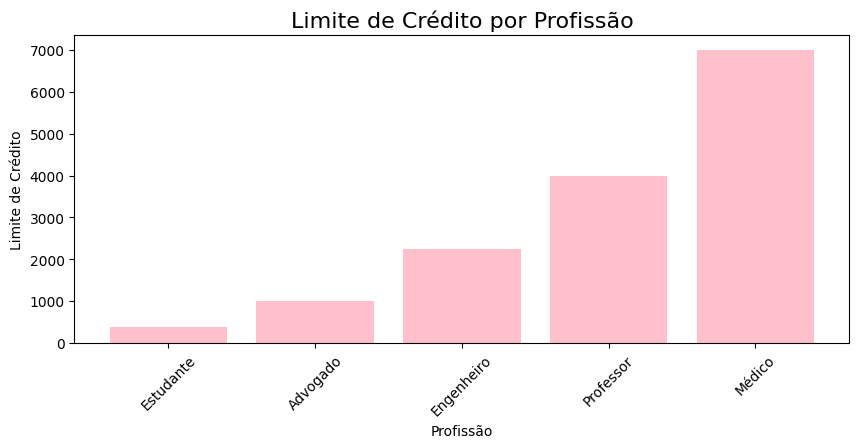

In [59]:
df['Salário'] = df['Salário'].astype(int)
df['Limite_Credito'] = df['Limite_Credito'].astype(int)
df['Historico_Inadimplencia'] = df['Historico_Inadimplencia'].astype(int)
df['Imovel_Proprio'] = df['Imovel_Proprio'].astype(int)


plt.figure(figsize=(10, 4)) 
credito_por_salario = df.groupby('Profissão')['Limite_Credito'].mean().sort_values() 
plt.bar(credito_por_salario.index, credito_por_salario, color='pink') 
plt.title('Limite de Crédito por Profissão', fontsize=16) #
plt.xlabel('Profissão') 
plt.ylabel('Limite de Crédito')
plt.xticks(rotation=45) 


O gráfico de barras acima mostra perfeitamente relação entre o limite de crédito e a profissão das pessoas, mostrando que em média os limites são concedidos baseado nas profissões que as pessoas exercem

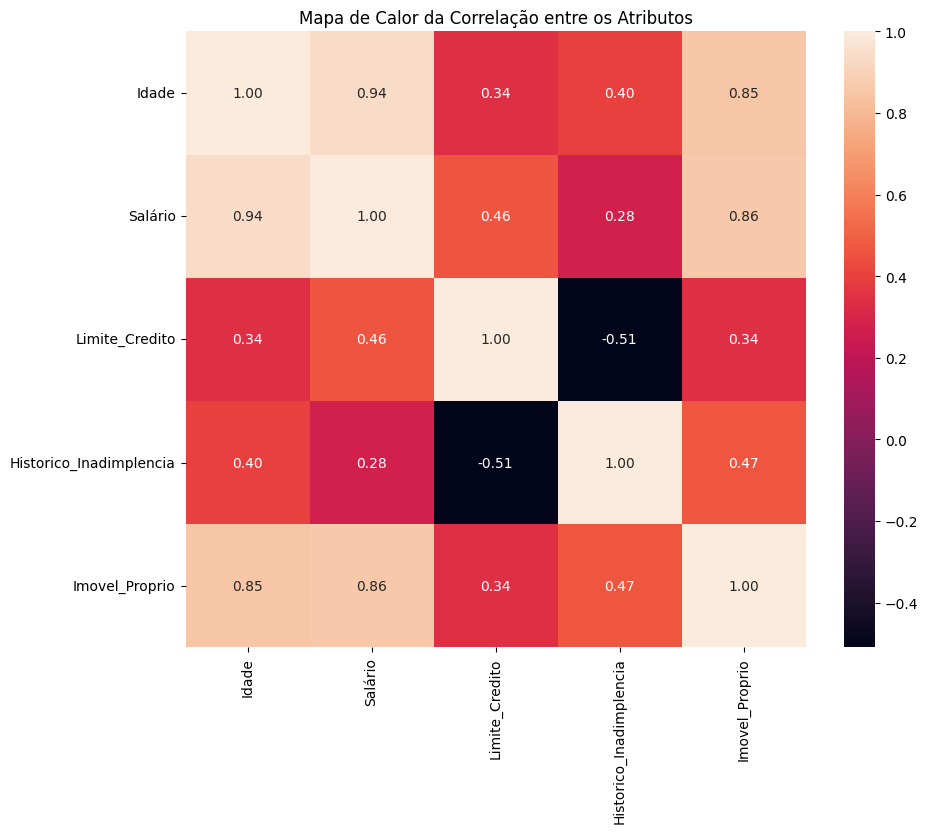

In [77]:


df_corr = df[['Idade', 'Salário', 'Limite_Credito', 'Historico_Inadimplencia', 'Imovel_Proprio']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(df_corr, annot=True, fmt=".2f")
plt.title('Mapa de Calor da Correlação entre os Atributos')
plt.show()

O gráfico de mapa de calor acima mostra a correlação entre várias variáveis e indica uma correlação forte entre o salário das pessoas e suas idades e a influência do salário sobre a aquisição de imóvel próprio.

In [79]:
limite_por_tudo = df.groupby(['Salário','Profissão', 'Idade', 'Historico_Inadimplencia'])['Limite_Credito'].mean().reset_index() 
fig = px.treemap(limite_por_tudo, 
                 path=['Salário', 'Profissão', 'Idade', 'Historico_Inadimplencia'], 
                 values='Limite_Credito', 
                 title='Relação entre variáveis', 
                 color='Limite_Credito',)
fig.show()

No gráfico de árvore acima podemos notar ainda outra informação importante, a influência do Histórico de inadimplência da pessoa sobre a concessão do crédito. Por mais que sua profissão lhe conceda o direito de receber um limite maior, se houver em sua ficha histórico de inadimplência o limite de crédito concedido consequentemente vai ser menor.